# Detect land marks on hand

In [1]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import mediapipe as mp
import numpy as np

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles

MARGIN = 10  # pixels
FONT_SIZE = 1
FONT_THICKNESS = 1
HANDEDNESS_TEXT_COLOR = (88, 205, 54) # vibrant green

def draw_landmarks_on_image(rgb_image, detection_result):
  hand_landmarks_list = detection_result.hand_landmarks
  handedness_list = detection_result.handedness
  annotated_image = np.copy(rgb_image)

  # Loop through the detected hands to visualize.
  for idx in range(len(hand_landmarks_list)):
    hand_landmarks = hand_landmarks_list[idx]
    handedness = handedness_list[idx]

    # Draw the hand landmarks.
    mp_drawing.draw_landmarks(
      annotated_image,
      hand_landmarks,
      mp_hands.HAND_CONNECTIONS,
      mp_drawing_styles.get_default_hand_landmarks_style(),
      mp_drawing_styles.get_default_hand_connections_style())

      
    # Get the top left corner of the detected hand's bounding box.
    height, width, _ = annotated_image.shape
    x_coordinates = [landmark.x for landmark in hand_landmarks]
    y_coordinates = [landmark.y for landmark in hand_landmarks]
    text_x = int(min(x_coordinates) * width)
    text_y = int(min(y_coordinates) * height) - MARGIN

    # Draw handedness (left or right hand) on the image.
    #cv2.putText(annotated_image, f"{handedness[0].category_name}",
    #            (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX,
    #            FONT_SIZE, HANDEDNESS_TEXT_COLOR, FONT_THICKNESS, cv2.LINE_AA)

  return annotated_image

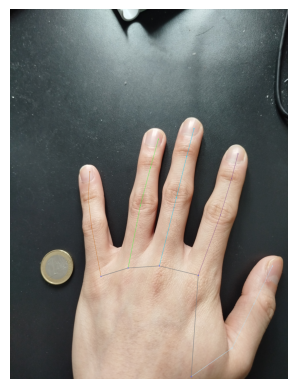

In [2]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an HandLandmarker object.
imgPath ="E:\Images\Hands\Hand_and_coin.jpg"
base_options = python.BaseOptions(model_asset_path="E:\Models\hand_landmarker.task")
options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
detector = vision.HandLandmarker.create_from_options(options)

# STEP 3: Load the input image.
image = mp.Image.create_from_file(imgPath)

# STEP 4: Detect hand landmarks from the input image.
detection_result = detector.detect(image)

# STEP 5: Process the classification result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

# Calculate coordinates of ring finger and mark them

ID 13: (1274, 2799)
ID 14: (1406, 2124)


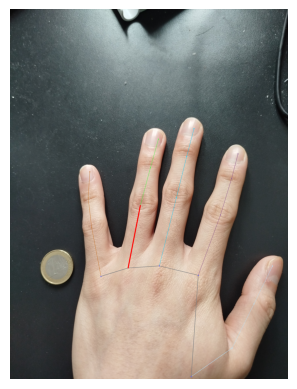

In [3]:
hand_landmarks = detection_result.hand_landmarks[0]

h, w, _ = annotated_image.shape
xcor=[]
ycor=[]
for id, lm in enumerate(hand_landmarks[13:15]):
     px = int(lm.x * w)
     py = int(lm.y * h)
     print(f"ID {id+ int(13)}: ({px}, {py})")
     xcor.append(px)
     ycor.append(py)
img2=cv2.line(annotated_image,(xcor[0],ycor[0]),(xcor[1],ycor[1]),(255,0,0),thickness=10,lineType=cv2.LINE_AA)
plt.imshow(img2), plt.axis("off")
plt.show()

# Read image of gemstones, resize and rotate
Depend on the shape of the gemstone, the width and height could be different

Pixel per mm: 11.463092950857547
Scale ratio: 1.9799887824208489


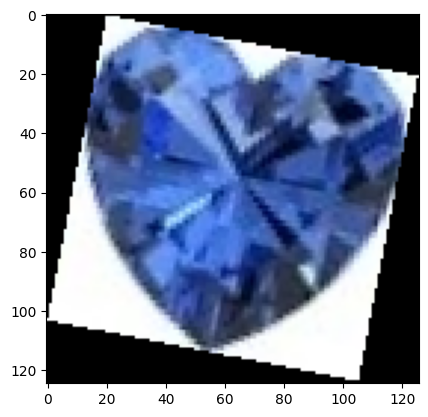

In [7]:
import math
from scipy import ndimage

gem_im=cv2.imread("Gemstone\Heart.jpg",cv2.IMREAD_UNCHANGED)
gem_img=cv2.cvtColor(gem_im, cv2.COLOR_BGR2RGB)
gemh, gemw = gem_img.shape[:2]

#calculate ratio
finger_l     = math. sqrt(((xcor[1]-xcor[0])**2)+((ycor[1]-ycor[0]))**2)
finger_real  = 60 #mm
pixel_per_mm = finger_l / finger_real #pixels per mm

gem_crt     = 9.5 #6mm~1crt
gem_pixels  = gem_crt * pixel_per_mm
scale_ratio = gem_pixels / gemw

new_w = int(gemw * scale_ratio)
new_h = int(gemh * scale_ratio)
resized_gem = cv2.resize(gem_img, (new_w, new_h), interpolation=cv2.INTER_AREA)
print("Pixel per mm:", pixel_per_mm)
print("Scale ratio:", scale_ratio)


angle = math.atan2(abs(ycor[1]-ycor[0]), abs(xcor[1]-xcor[0]))
angle_degrees = angle * 180/math.pi -90

#rotation angle in degree
gemrotated = ndimage.rotate(resized_gem, angle_degrees)
plt.imshow(gemrotated)
plt.show()

# Remove background

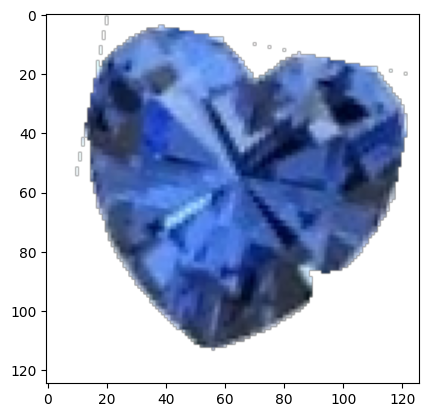

In [8]:
gemh2, gemw2 = gemrotated.shape[:2]

# threshold on white
# Define lower and uppper limits
lower = np.array([200, 200, 200])
upper = np.array([255, 255, 255])

# Create mask to only select black
thresh = cv2.inRange(gemrotated, lower, upper)

# apply morphology
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,20))
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# invert morp image
mask = 255 - morph

# apply mask to image
gemresult = cv2.bitwise_and(gemrotated, gemrotated, mask=mask)
# Convert to RGBA
rgba = cv2.cvtColor(gemresult, cv2.COLOR_BGR2BGRA)

# Make black pixels transparent
black = np.all(gemresult == [0,0,0], axis=-1)
rgba[black, 3] = 0  # Set alpha channel to 0 where black
plt.imshow(rgba)
plt.show()

# Put the gemstone on top of the finger 

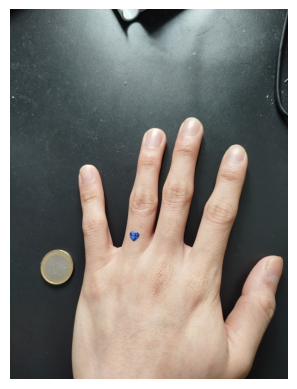

In [9]:
img3 = cv2.imread(imgPath,1)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
overlay = rgba
background = img3

x2 = int((xcor[1]+xcor[0]) / 2)
y2 = int((ycor[1]+ycor[0]) / 2) # position to place overlay

h2, w2 = overlay.shape[:2]
cx_gem = w2 // 2
cy_gem = h2 // 2

offset_x = x2 - cx_gem
offset_y = y2 - cy_gem

# Separate channels
alpha = overlay[:, :, 3] / 255.0
overlay_rgb = overlay[:, :, :3]

for c in range(3):
    background[offset_y:offset_y+h2, offset_x:offset_x + w2, c] = (
        alpha * overlay_rgb[:, :, c] +
        (1 - alpha) * background[offset_y:offset_y+h2, offset_x:offset_x + w2, c])
plt.imshow(img3); plt.axis("off")
plt.show()